<a href="https://colab.research.google.com/github/KatreenGhobrial/RepoCloudComputing/blob/main/Tirgulim/Tirgul5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install requests beautifulsoup4 matplotlib pandas

import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime




FIREBASE_DB_URL = "https://plant-70648-default-rtdb.firebaseio.com/"
FIREBASE_PATH = "plant_disease_word"



def fetch_page(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)
    print("HTTP status:", response.status_code)

    if response.status_code == 200:
        return BeautifulSoup(response.text, "html.parser")
    else:
        print("Failed to fetch page")
        return None




In [ ]:
def index_words(soup):
    text = soup.get_text()


    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

    index = {}

    for word in words:
        if word in index:
            index[word] += 1
        else:
            index[word] = 1

    return index




In [ ]:


def remove_stop_words(index):
    stop_words = {
       'a', 'an', 'the', 'and', 'or', 'in', 'on', 'at'}

    for word in stop_words:
        if word in index:
            del index[word]

    return index




In [ ]:
def select_important_words(index):
    important_words = [
        "plant",
        "disease",
        "pathogen",
        "fungi",
        "bacteria",
        "virus",
        "infection",
        "symptoms",
        "control",
        "resistance"
    ]

    selected_index = {}

    for word in important_words:
        selected_index[word] = index.get(word, 0)

    return selected_index



In [ ]:
def save_to_firebase(word_index):
    firebase_url = f"{FIREBASE_DB_URL}/{FIREBASE_PATH}.json"

    data_to_save = {
        "topic": "Plant Disease Detection",
        "source_url": "https://www.gardentech.com/blog/pest-id-and-prevention/keep-your-garden-free-from-fungal-disease",
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "word_index": word_index
    }

    response = requests.put(firebase_url, json=data_to_save)

    print("Firebase save status:", response.status_code)

    if response.status_code == 200:
        print("Data saved successfully to Firebase")
    else:
        print("Failed to save data to Firebase")
        print(response.text)





In [ ]:
def read_from_firebase():
    firebase_url = f"{FIREBASE_DB_URL}/{FIREBASE_PATH}.json"

    response = requests.get(firebase_url)

    print("Firebase read status:", response.status_code)

    if response.status_code == 200:
        print("Data loaded successfully from Firebase")
        return response.json()
    else:
        print("Failed to read data from Firebase")
        print(response.text)
        return None





HTTP status: 200
Selected Word Index:
{'plant': 18, 'disease': 22, 'pathogen': 0, 'fungi': 0, 'bacteria': 0, 'virus': 0, 'infection': 0, 'symptoms': 1, 'control': 8, 'resistance': 1}
Firebase save status: 200
Data saved successfully to Firebase
Firebase read status: 200
Data loaded successfully from Firebase
Data from Firebase:
{'created_at': '2026-05-03 10:18:49', 'source_url': 'https://www.gardentech.com/blog/pest-id-and-prevention/keep-your-garden-free-from-fungal-disease', 'topic': 'Plant Disease Detection', 'word_index': {'bacteria': 0, 'control': 8, 'disease': 22, 'fungi': 0, 'infection': 0, 'pathogen': 0, 'plant': 18, 'resistance': 1, 'symptoms': 1, 'virus': 0}}


,Word,Count
2,disease,22
6,plant,18
1,control,8
7,resistance,1
8,symptoms,1
0,bacteria,0
5,pathogen,0
4,infection,0
3,fungi,0
9,virus,0


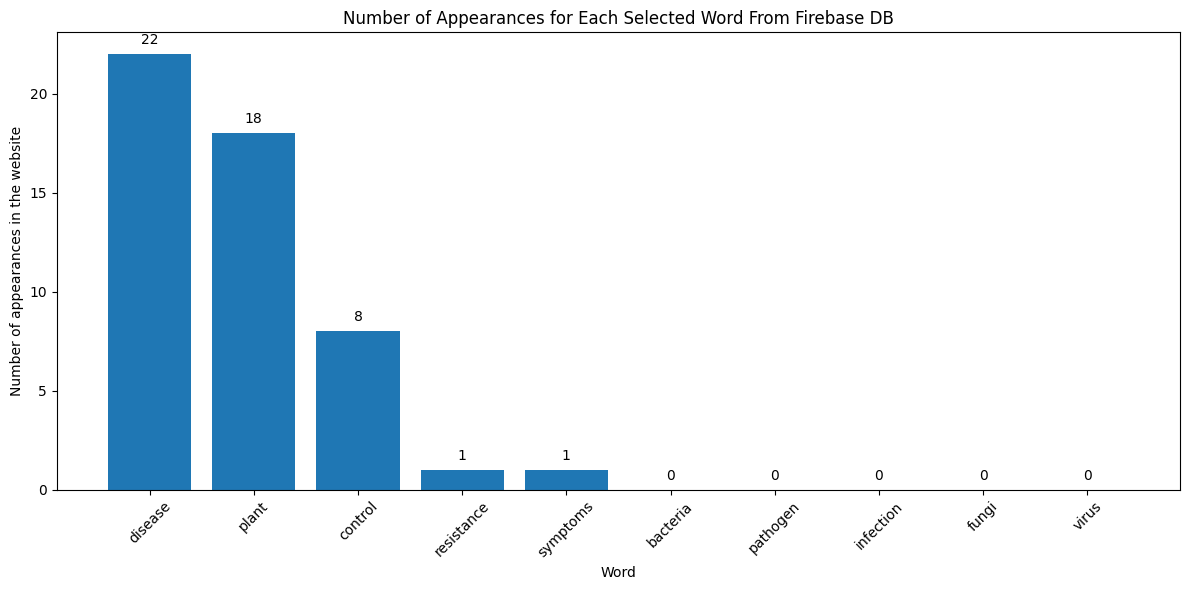

In [ ]:

url = "https://www.gardentech.com/blog/pest-id-and-prevention/keep-your-garden-free-from-fungal-disease"

soup = fetch_page(url)

if soup is not None:

    index = index_words(soup)

    index = remove_stop_words(index)

    selected_index = select_important_words(index)

    print("Selected Word Index:")
    print(selected_index)


    save_to_firebase(selected_index)


    firebase_data = read_from_firebase()

    print("Data from Firebase:")
    print(firebase_data)


    if firebase_data is not None and "word_index" in firebase_data:
        word_index_from_db = firebase_data["word_index"]


        df = pd.DataFrame(word_index_from_db.items(), columns=["Word", "Count"])

        df = df.sort_values(by="Count", ascending=False)

        display(df)


        plt.figure(figsize=(12, 6))

        plt.bar(df["Word"], df["Count"])

        plt.xlabel("Word")
        plt.ylabel("Number of appearances in the website")
        plt.title("Number of Appearances for Each Selected Word From Firebase DB")

        for i, count in enumerate(df["Count"]):
            plt.text(i, count + 0.5, str(count), ha="center")

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    else:
        print("Could not load word_index from Firebase DB. Chart was not created.")

else:
    print("Could not load the website.")